# MARL Tabular Q Analysis

Use this notebook to inspect results produced by `experiments/n_player_experiments_simple.py`.
It intentionally mirrors the structure of the DQN notebook while staying independent
so we can iterate on the tabular agent without touching legacy analyses.

## How to use
- Run the simple experiment script to generate results in `analysis/results`.
- Select the JSON artifact you want to inspect below.
- The helper code will load the per-episode Parquet/CSV it references and compute a few summaries.

If you add new fields to the simple simulation, extend the summaries here; the notebook is meant
to be a lightweight playground for the tabular agent.

In [16]:
from pathlib import Path
import sys
from collections.abc import Iterable

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'analysis' else NOTEBOOK_DIR
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from analysis import analysis_utils

DATA_DIR = NOTEBOOK_DIR / 'results'
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = NOTEBOOK_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Provide either a single result id string or an iterable of ids to process in sequence.
target_res_input = [
    '5_player_logit_tabq_no_static_baseresetonly_mu_0.01_1_state_lastlowest_N5_actions3-7-11_20251211T003125Z'
]

if isinstance(target_res_input, str) or not isinstance(target_res_input, Iterable):
    target_res_list = [target_res_input]
else:
    target_res_list = list(target_res_input)


In [17]:
# Load experiment results for each target result id
experiments = {}

for target_res in target_res_list:
    target_file = DATA_DIR / f'{target_res}.json'
    target_fig_dir = FIG_DIR / target_res
    target_fig_dir.mkdir(exist_ok=True)

    if not target_file.exists():
        print(f"Experiment file {target_file.name} not found. Run the experiment or update the path above.")
        continue

    print(f'Loaded experiment: {target_file.name}')
    experiment = analysis_utils.load_experiment(target_file)
    frame = analysis_utils.runs_to_frame(experiment)
    experiments[target_res] = {"frame": frame, "fig_dir": target_fig_dir}
    display(frame.head())


Loaded experiment: 5_player_logit_tabq_no_static_baseresetonly_mu_0.01_1_state_lastlowest_N5_actions3-7-11_20251211T003125Z.json


,scenario,share_parameters,seed,episode,mean_profit,norm_profit,avg_price,avg_lowest_price,repricer_share,network_density,...,action_share_undercut_reset,action_share_undercut_reset_raise,action_share_match,action_share_match_raise,action_share_match_reset,action_share_match_reset_raise,action_share_above,action_share_above_raise,action_share_above_reset,action_share_above_reset_raise
0,logit,False,0,0.0,0.025854,0.116259,1.335848,1.129269,1.0,0.6,...,0.2,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.4,0.0
1,logit,False,0,1.0,0.021235,0.091665,1.460972,1.106175,1.0,0.4,...,0.6,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.2,0.0
2,logit,False,0,2.0,0.023755,0.105079,1.481546,1.118772,1.0,0.4,...,0.4,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.2,0.0
3,logit,False,0,3.0,0.021235,0.091665,1.463911,1.106175,1.0,0.6,...,0.6,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.2,0.0
4,logit,False,0,4.0,0.023755,0.105081,1.340047,1.118772,1.0,0.4,...,0.2,0.0,0.0,0.0,0.4,0.0,0.0,0.0,0.4,0.0


Plotting metrics for 5_player_logit_tabq_no_static_baseresetonly_mu_0.01_1_state_lastlowest_N5_actions3-7-11_20251211T003125Z -> /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/analysis/figures/5_player_logit_tabq_no_static_baseresetonly_mu_0.01_1_state_lastlowest_N5_actions3-7-11_20251211T003125Z


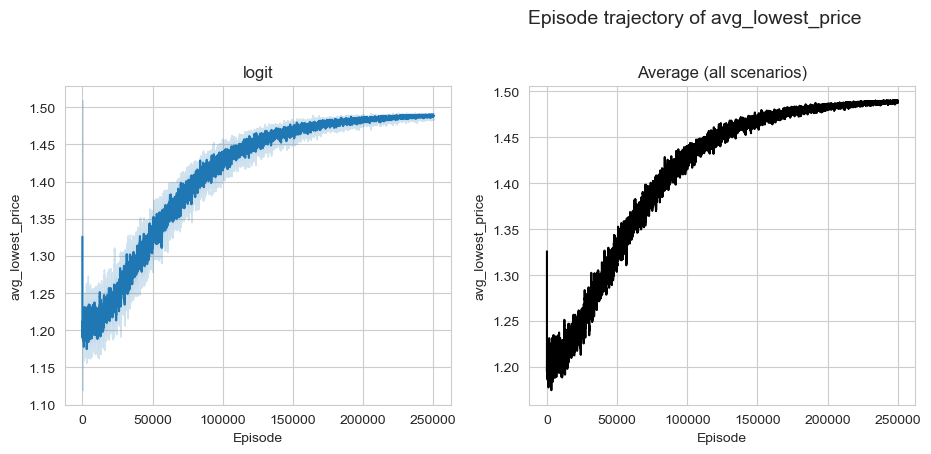

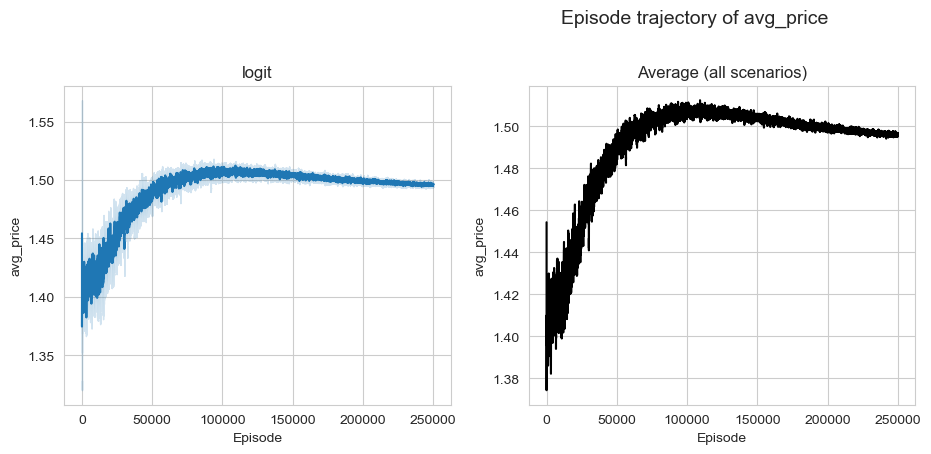

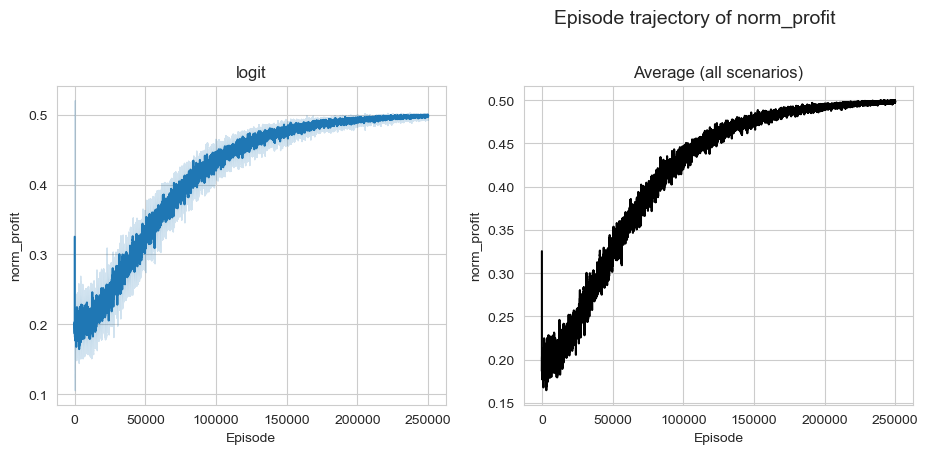

In [18]:
# Plot metrics over episodes
metrics = [
    'avg_lowest_price',
    'avg_price',
    'norm_profit',
    # 'repricer_share',
    # 'network_density',
    # 'weighted_density',
    # 'in_degree_centralization',
]

if not experiments:
    print("No experiments loaded; check target_res_list and rerun.")
else:
    for target_res, payload in experiments.items():
        frame = payload["frame"]
        target_fig_dir = payload["fig_dir"]
        print(f'Plotting metrics for {target_res} -> {target_fig_dir}')
        for metric in metrics:
            analysis_utils.plot_metric_over_episodes(
                frame,
                metric,
                smoothing=100,
                use_log_x=False,
                title=f'Episode trajectory of {metric}',
                save_path=target_fig_dir / f'{metric}_episodes.png',
            )


Plotting action family shares for 5_player_logit_tabq_no_static_baseresetonly_mu_0.01_1_state_lastlowest_N5_actions3-7-11_20251211T003125Z -> /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/analysis/figures/5_player_logit_tabq_no_static_baseresetonly_mu_0.01_1_state_lastlowest_N5_actions3-7-11_20251211T003125Z


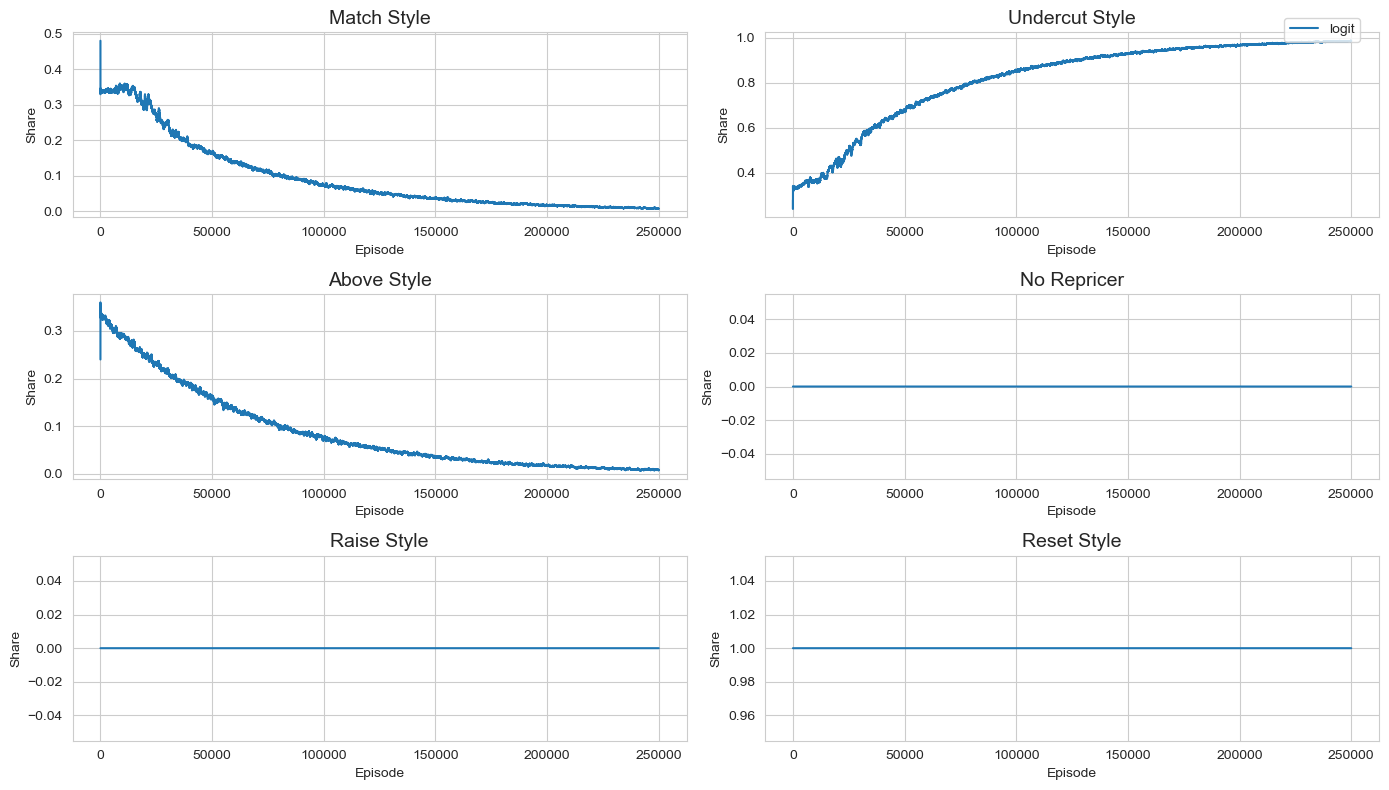

In [19]:
# Plot action family shares over episodes
if not experiments:
    print("No experiments loaded; check target_res_list and rerun.")
else:
    for target_res, payload in experiments.items():
        frame = payload["frame"]
        target_fig_dir = payload["fig_dir"]
        print(f'Plotting action family shares for {target_res} -> {target_fig_dir}')
        analysis_utils.plot_action_family_shares(
            frame,
            use_log_x=False,
            smoothing=500,
            families=["Match Style", "Undercut Style", "Above Style", "No Repricer" , 'Raise Style', 'Reset Style'],
            layout=(3, 2),
            save_path=target_fig_dir / 'action_family_over_episodes.png',
        )
